In [1]:
import sys
sys.path.append('C:\\Users\\elanphear\\Code\\ODYM\\odym\\modules') 

In [2]:
import dynamic_stock_model as dsm # import the dynamic stock model library

In [3]:
import openpyxl
import numpy as np
import matplotlib.pyplot as plt

# For Ipython Notebook only
get_ipython().run_line_magic('matplotlib', 'inline')

In [4]:
file_path = 'C:\\Users\\elanphear\\Code\\ODYM\\docs\\LL_IEooc_Methods3_Software1_Data.xlsx'
DSM_Datafile  = openpyxl.load_workbook(filename=file_path)
DSM_Datasheet = DSM_Datafile['Data_Batteries_US']

Historic_Years = [] #years 1900 to 2008
Historic_Inflow = [] # apparent final steel consumption, China, kt/yr
Future_Years = [] # years 2009-2100
Future_Stock = [] # future scenario for the steel stock, China, kt

for m in range(3,27): # Read historic data
    Historic_Years.append(int(DSM_Datasheet.cell(m,3).value))
    Historic_Inflow.append(DSM_Datasheet.cell(m,4).value)

for m in range(3,78): # Read future scenario
    Future_Years.append(int(DSM_Datasheet.cell(m,9).value))
    Future_Stock.append(DSM_Datasheet.cell(m,10).value)

print(Historic_Years)

print(Future_Stock)

[2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]
[1519.4404879999997, 1962.2205919999997, 2475.3879439999996, 3148.5304129999995, 4025.6357349999994, 5116.219413999999, 5719.872080999999, 6409.703180999999, 7140.977821999999, 7948.410846999998, 8845.966343999999, 9200, 9500, 9700, 10000, 12000, 13000, 13000, 13000, 13000, 13000, 13000, 13000, 13000, 13000, 13000, 13000, 13000, 13000, 13000, 13000, 13000, 13000, 13000, 13000, 13000, 13000, 13000, 13000, 13000, 13000, 13000, 13000, 13000, 13000, 13000, 13000, 13000, 13000, 13000, 13000, 13000, 13000, 13000, 13000, 13000, 13000, 13000, 13000, 13000, 13000, 13000, 13000, 13000, 13000, 13000, 13000, 13000, 13000, 13000, 13000, 13000, 13000, 13000, 13000]


In [5]:
AvgLifetime = 15
InputStdDev = 0.3*AvgLifetime

US_DSM = dsm.DynamicStockModel(t = np.array(Historic_Years), i = np.array(Historic_Inflow), lt = {'Type': 'Normal', 'Mean': np.array([AvgLifetime]), 'StdDev': np.array([InputStdDev]) })


# Let's check the attributes of the object we just defined:<br>
# t indicates the time in years <br>

In [6]:
US_DSM.t

array([2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010,
       2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021,
       2022, 2023])

In [7]:
US_DSM.i

array([  0.     ,   0.     ,   0.     ,   0.     ,   0.     ,   0.     ,
         0.     ,   0.     ,   0.     ,   0.     ,  20.     ,  35.     ,
        80.     , 150.     , 257.01737, 280.     , 309.168  , 350.     ,
       400.     , 490.     , 530.     , 720.     , 800.     , 928.5775 ])

In [8]:
US_DSM.lt

{'Type': 'Normal',
 'Mean': array([15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15,
        15, 15, 15, 15, 15, 15, 15]),
 'StdDev': array([4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5,
        4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5, 4.5])}

In [9]:
CheckStr = US_DSM.dimension_check()
print(CheckStr)

<br><b> Checking dimensions of dynamic stock model DSM.Time vector is present with 24 years.<br>Inflow vector is present with 24 years.<br>Total stock is not present.<br>Stock by cohorts is not present.<br>Total outflow is not present.<br>Outflow by cohorts is not present.<br>Lifetime distribution is present with type Normal.<br>


In [10]:
Stock_by_cohort = US_DSM.compute_s_c_inflow_driven()
print(Stock_by_cohort)
print(Stock_by_cohort.shape)

[[  0.           0.           0.           0.           0.
    0.           0.           0.           0.           0.
    0.           0.           0.           0.           0.
    0.           0.           0.           0.           0.
    0.           0.           0.           0.        ]
 [  0.           0.           0.           0.           0.
    0.           0.           0.           0.           0.
    0.           0.           0.           0.           0.
    0.           0.           0.           0.           0.
    0.           0.           0.           0.        ]
 [  0.           0.           0.           0.           0.
    0.           0.           0.           0.           0.
    0.           0.           0.           0.           0.
    0.           0.           0.           0.           0.
    0.           0.           0.           0.        ]
 [  0.           0.           0.           0.           0.
    0.           0.           0.           0.           0.
    0.   

In [11]:
S   = US_DSM.compute_stock_total()
print(S)

[   0.            0.            0.            0.            0.
    0.            0.            0.            0.            0.
   19.99141879   54.96634441  134.89439727  284.71682343  541.33352444
  820.54476287 1128.22540121 1475.53190002 1870.84461341 2352.98371004
 2870.3119295  3570.55126415 4340.84045303 5226.19180333]


In [12]:
O_C = US_DSM.compute_o_c_from_s_c()
print(O_C)

[[ 0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.        ]
 [-0.          0.         -0.         -0.         -0.         -0.
  -0.         -0.         -0.         -0.         -0.         -0.
  -0.         -0.         -0.         -0.         -0.         -0.
  -0.         -0.         -0.         -0.         -0.         -0.        ]
 [-0.         -0.          0.         -0.         -0.         -0.
  -0.         -0.         -0.         -0.         -0.         -0.
  -0.         -0.         -0.         -0.         -0.         -0.
  -0.         -0.         -0.         -0.         -0.         -0.        ]
 [-0.         -0.         -0.          0.         -0.         -0.
  -0.         -0.         -0.         -0.         -0.         -0.
  -0.         -0.         -0.         -0.        

In [13]:
O   = US_DSM.compute_outflow_total()
print(O)

[0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 8.58120666e-03 2.50743843e-02
 7.19471399e-02 1.77573837e-01 4.00668989e-01 7.88761572e-01
 1.48736166e+00 2.69350119e+00 4.68728661e+00 7.86090338e+00
 1.26717805e+01 1.97606653e+01 2.97108111e+01 4.32261497e+01]


In [14]:
DS  = US_DSM.compute_stock_change()
print(DS)

[  0.           0.           0.           0.           0.
   0.           0.           0.           0.           0.
  19.99141879  34.97492562  79.92805286 149.82242616 256.61670101
 279.21123843 307.68063834 347.30649881 395.31271339 482.13909662
 517.32821946 700.23933465 770.28918887 885.3513503 ]


In [15]:
print(US_DSM.dimension_check()) # dimension_check returns two variables, but we only print the first one, which has index 0.

<br><b> Checking dimensions of dynamic stock model DSM.Time vector is present with 24 years.<br>Inflow vector is present with 24 years.<br>Total stock is present with 24 years.<br>Stock by cohorts is present with 24 years and 24 cohorts.<br>Total outflow is present with 24 years.<br>Outflow by cohorts is present with 24 years and 24 cohorts.<br>Lifetime distribution is present with type Normal.<br>


In [16]:
Bal = US_DSM.check_stock_balance()
print(Bal)

[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
 -1.42108547e-14  0.00000000e+00  5.68434189e-14 -5.68434189e-14
  5.68434189e-14  0.00000000e+00 -2.84217094e-13  1.13686838e-13
 -2.27373675e-13  3.41060513e-13 -1.13686838e-13 -4.54747351e-13]


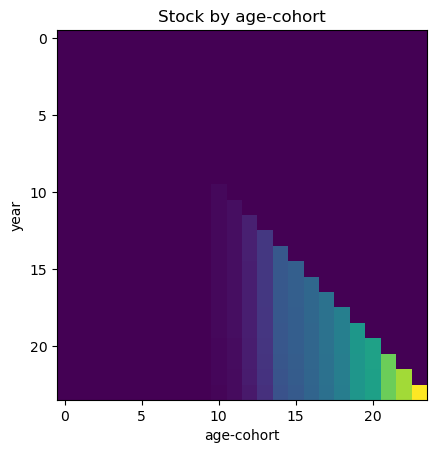

In [17]:
plt.imshow(US_DSM.s_c, interpolation='nearest')
plt.xlabel('age-cohort')
plt.ylabel('year')
plt.title('Stock by age-cohort')
plt.show();

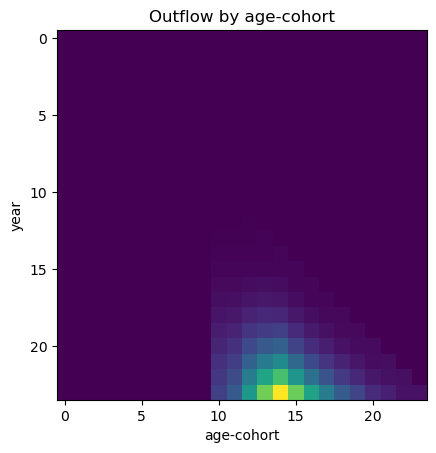

In [18]:
plt.imshow(US_DSM.o_c,interpolation='nearest')
plt.xlabel('age-cohort')
plt.ylabel('year')
plt.title('Outflow by age-cohort')
plt.show();

In [19]:
US_Stock_Full = np.concatenate((S,Future_Stock), axis =0)
Time_Full        = np.concatenate((np.array(Historic_Years),np.array(Future_Years)), axis =0)

US_DSM_Full = dsm.DynamicStockModel(t = Time_Full, s = US_Stock_Full, lt = {'Type': 'Normal', 'Mean': np.array([AvgLifetime]), 'StdDev': np.array([0.3*AvgLifetime]) })
CheckStr = US_DSM_Full.dimension_check()
print(CheckStr)

<br><b> Checking dimensions of dynamic stock model DSM.Time vector is present with 99 years.<br>Inflow is not present.<br>Total stock is present with 99 years.<br>Stock by cohorts is not present.<br>Total outflow is not present.<br>Outflow by cohorts is not present.<br>Lifetime distribution is present with type Normal.<br>


In [20]:
S_C, O_C, I = US_DSM_Full.compute_stock_driven_model()
O   = US_DSM_Full.compute_outflow_total()
DS  = US_DSM_Full.compute_stock_change()
Bal = US_DSM_Full.check_stock_balance()
print(Bal)

[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  7.10542736e-15
  1.42108547e-14 -2.84217094e-14 -5.68434189e-14  5.68434189e-14
  1.13686838e-13 -1.13686838e-13  1.13686838e-13  1.13686838e-13
 -2.27373675e-13  0.00000000e+00 -2.27373675e-13  4.54747351e-13
  4.54747351e-13 -1.02318154e-12  6.82121026e-13 -2.27373675e-13
  1.13686838e-13 -4.54747351e-13 -2.27373675e-13 -5.68434189e-13
  7.95807864e-13 -4.54747351e-13 -1.13686838e-13  1.76214598e-12
 -2.04636308e-12  1.25055521e-12  6.25277607e-13 -2.50111043e-12
  4.54747351e-13  1.19371180e-12 -2.84217094e-13  3.41060513e-13
  4.54747351e-13  7.95807864e-13 -2.38742359e-12  2.61479727e-12
 -1.93267624e-12  0.00000000e+00 -1.13686838e-13  3.41060513e-13
  2.27373675e-13 -1.25055521e-12  2.27373675e-13 -1.13686838e-13
  1.02318154e-12  1.02318154e-12 -1.36424205e-12  4.54747351e-13
 -1.59161573e-12  1.02318

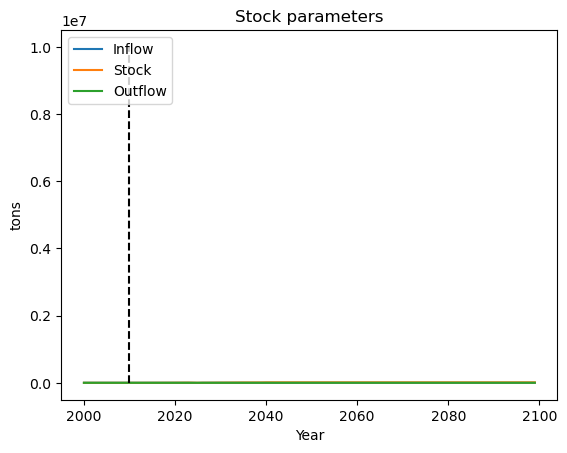

In [26]:
plt1, = plt.plot(US_DSM_Full.t, US_DSM_Full.i)
plt2, = plt.plot(US_DSM_Full.t, US_DSM_Full.s)
plt3, = plt.plot(US_DSM_Full.t, US_DSM_Full.o)
plt4, = plt.plot([2010,2010],[0,1e7], color = 'k', linestyle = '--')
plt.xlabel('Year')
plt.ylabel('tons')
plt.title('Stock parameters')
plt.legend([plt1,plt2,plt3], ['Inflow','Stock','Outflow'], loc = 2)
plt.show();

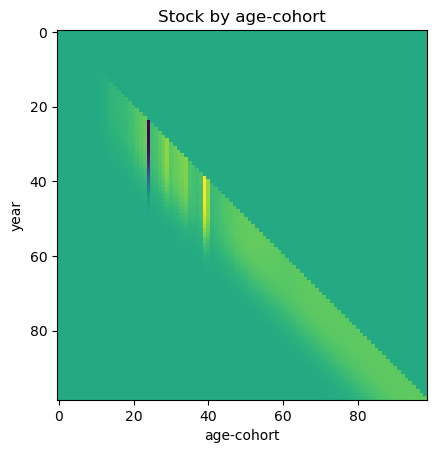

In [22]:
plt.imshow(US_DSM_Full.s_c,interpolation='nearest')
plt.xlabel('age-cohort')
plt.ylabel('year')
plt.title('Stock by age-cohort')
plt.show();

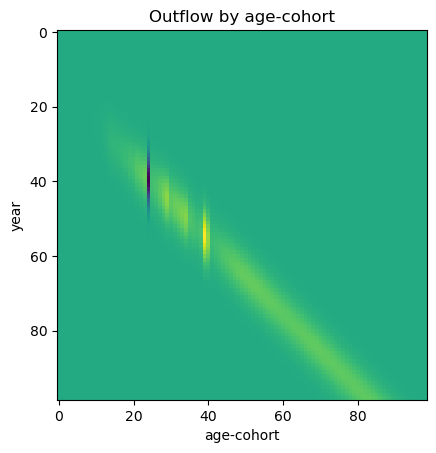

In [23]:
plt.imshow(US_DSM_Full.o_c,interpolation='nearest')
plt.xlabel('age-cohort')
plt.ylabel('year')
plt.title('Outflow by age-cohort')
plt.show();

In [25]:
FlowBal = US_DSM_Full.i[0:24] - Historic_Inflow
print(FlowBal)
print(np.abs(FlowBal).sum())

[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  1.42108547e-14 -2.84217094e-14 -5.68434189e-14  1.13686838e-13
  0.00000000e+00 -1.70530257e-13  3.97903932e-13  0.00000000e+00
  1.13686838e-13 -4.54747351e-13 -1.13686838e-13  9.09494702e-13]
2.3732127374387346e-12
